In [1]:
!pip install h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 3.7 MB/s eta 0:00:00


In [2]:
#mount google drive
from google.colab import drive
import os
drive.mount('/content/drive')
PARQUET_PATH  = os.path.join(os.getcwd(),'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
CHALLENGE_DATA_PATH = os.path.join(os.getcwd(),'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
SUBMISSION_PATH = os.getcwd()

Mounted at /content/drive


In [72]:
import io
import re
import os
import tempfile
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler


import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#Final Data Cleaning for Task 4.5

In [45]:
df_train = pd.read_parquet(PARQUET_PATH + "/merged_data/combined.parquet")
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_transcriptomics = pd.read_parquet(CHALLENGE_DATA_PATH + '/challenge_transcriptomics_cleaned.parquet')
df_challenge = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
df_challenge = df_challenge.merge(challenge_transcriptomics, on='participant_id', how='inner')

In [46]:
# Calculate the percentage of missing values for each column
missing_percentage = df_train.isnull().sum() / len(df_train) * 100

# Identify columns to drop (missing 85% or more values) excluding those starting with 'HAI_'
columns_to_drop = [col for col in missing_percentage[missing_percentage >= 85].index if not col.startswith('HAI_')]

# Drop the identified columns from df_train
df_train.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped {len(columns_to_drop)} columns with 85% or more missing values (excluding HAI_ columns).")
print(f"New shape of df_train: {df_train.shape}")

Dropped 109862 columns with 85% or more missing values (excluding HAI_ columns).
New shape of df_train: (3757, 201)


For this task we need to estimate the average of the following strains from the challenge set at day 28:

H1N1 A/California/7/2009            
H1N1 A/Brisbane/2/2018              
H1N1 A/Guangdong-Maonan/SWL1536/2019
H1N1 A/Victoria/2570/2019           
H1N1 A/Victoria/4897/2022           
H3N2 A/Hong Kong/4801/2014          
H3N2 A/Singapore/INFIMH-160019/2016
H3N2 A/Kansas/14/2017               
H3N2 A/Hong Kong/2671/2019          
H3N2 A/South Australia/34/2019      
H3N2 A/Tasmania/503/2020            
H3N2 A/Darwin/9/2021                
H3N2 A/Massachusetts/18/2022        
Vic B/Colorado/6/2017               
Vic B/Washington/2/2019             
Vic B/Austria/1359417/2021          
Yam B/Phuket/3073/2013

Several of these will likely be missing from the training data. Lets first explore which strains are missing

In [47]:
strains_d0 = set()
strains_d28 = set()

for col in df_train.columns:
    match_d0 = re.match(r'HAI_(.*)_d0$', col)
    if match_d0:
        strains_d0.add(match_d0.group(1))

    match_d28 = re.match(r'HAI_(.*)_d28$', col)
    if match_d28:
        strains_d28.add(match_d28.group(1))

print(strains_d0)
print(strains_d28)

challenge_strains = set([
    'H1N1 A/California/7/2009',
    'H1N1 A/Brisbane/2/2018',
    'H1N1 A/Guangdong-Maonan/SWL1536/2019',
    'H1N1 A/Victoria/2570/2019',
    'H1N1 A/Victoria/4897/2022',
    'H3N2 A/Hong Kong/4801/2014',
    'H3N2 A/Singapore/INFIMH-160019/2016',
    'H3N2 A/Kansas/14/2017',
    'H3N2 A/Hong Kong/2671/2019',
    'H3N2 A/South Australia/34/2019',
    'H3N2 A/Tasmania/503/2020',
    'H3N2 A/Darwin/9/2021',
    'H3N2 A/Massachusetts/18/2022',
    'Vic B/Colorado/6/2017',
    'Vic B/Washington/2/2019',
    'Vic B/Austria/1359417/2021',
    'Yam B/Phuket/3073/2013'
])

missing_strains = challenge_strains - strains_d28
print(missing_strains)


{'Anc B/Maryland/1959', 'Anc B/Lee/1940', 'H1N1 A/Hawaii/70/2019', 'H3N2 A/Hong Kong/4801/2014', 'H3N2 A/Tasmania/503/2020', 'Vic B/Malaysia/2506/2004', 'H3N2 A/Mississippi/1/1985', 'H3N2 A/Texas/1/1977', 'H3N2 A/Hong Kong/1/1968', 'Vic B/Washington/2/2019', 'H1N1 A/Chile/1/1983', 'Vic B/Austria/1359417/2021', 'H1N1 A/Brisbane/2/2018', 'H1N1 A/Brisbane/59/2007', 'H1N1 A/Beijing/262/1995', 'H1N1 A/Solomon Islands/3/2006', 'Yam B/Wisconsin/1/2010', 'Vic B/Brisbane/60/2008', 'H3N2 A/Uruguay/716/2007', 'Vic B/Colorado/6/2017', 'H1N1 A/Brazil/11/1978', 'H1N1 A/Singapore/6/1986', 'H1N1 A/South Carolina/1/1918', 'H1N1 A/Victoria/2570/2019', 'H3N2 A/Brisbane/10/2007', 'H1N1 A/Guangdong-Maonan/SWL1536/2019', 'H1N1 A/Denver/1/1957', 'H3N2 A/Perth/16/2009', 'Yam B/Massachusetts/2/2012', 'H3N2 A/Kansas/14/2017', 'H3N2 A/Victoria/3/1975', 'H3N2 A/Sichuan/60/1989', 'H1N1 A/Weiss/JY2/1943', 'Yam B/Florida/4/2006', 'Yam B/Brisbane/3/2007', 'H3N2 A/Hong Kong/2671/2019', 'H3N2 A/Sydney/5/1997', 'H3N2 A/

In [48]:
d0_cols = [
    f"HAI_{strain}_d0"
    for strain in challenge_strains
    if f"HAI_{strain}_d0" in df_train.columns
]

d28_cols = [
    f"HAI_{strain}_d28"
    for strain in challenge_strains
    if f"HAI_{strain}_d28" in df_train.columns
]

print("Available D0 strains:", len(d0_cols))
print("Available D28 strains:", len(d28_cols))

# -----------------------------
# Compute log-space geomeans
# (values already log2 transformed)
# -----------------------------

df_train["geomean_d0"] = df_train[d0_cols].mean(axis=1, skipna=True)

df_train["geomean_d28"] = df_train[d28_cols].mean(axis=1, skipna=True)

# -----------------------------
# Count number of strains used
# -----------------------------

df_train["n_strains_d0"] = (
    df_train[d0_cols]
    .notna()
    .sum(axis=1)
)

df_train["n_strains_d28"] = (
    df_train[d28_cols]
    .notna()
    .sum(axis=1)
)

# -----------------------------
# Compute overall breadth response
# -----------------------------

df_train["breadth_delta"] = (
    df_train["geomean_d28"]
    - df_train["geomean_d0"]
)

print(df_train[['geomean_d0', 'geomean_d28', 'n_strains_d0', 'n_strains_d28']].head(10))

#count number of Nans for geoman_d0 and geomean_d28
print(df_train['geomean_d0'].isna().sum())
print(df_train['geomean_d28'].isna().sum())


Available D0 strains: 16
Available D28 strains: 16
   geomean_d0  geomean_d28  n_strains_d0  n_strains_d28
0         NaN          NaN             0              0
1         NaN          NaN             0              0
2         NaN          NaN             0              0
3         NaN          NaN             0              0
4         NaN          NaN             0              0
5         NaN          NaN             0              0
6         NaN          NaN             0              0
7         NaN          NaN             0              0
8         NaN          NaN             0              0
9         NaN          NaN             0              0
697
819


In [49]:
for MIN_STRAINS in range(1, 7):
    df_breadth = df_train[
      (df_train["n_strains_d0"] >= MIN_STRAINS) &
      (df_train["n_strains_d28"] >= MIN_STRAINS)
    ].copy()

    print(f'MIN_STRAIN = {MIN_STRAINS}:    ', 'Before: ', len(df_train), ' After: ', len(df_breadth), ' Dif: ', len(df_train) - len(df_breadth), ' Percent change: ', (len(df_train) - len(df_breadth)) / len(df_train))

MIN_STRAIN = 1:     Before:  3757  After:  2934  Dif:  823  Percent change:  0.2190577588501464
MIN_STRAIN = 2:     Before:  3757  After:  1862  Dif:  1895  Percent change:  0.5043918019696566
MIN_STRAIN = 3:     Before:  3757  After:  1795  Dif:  1962  Percent change:  0.522225179664626
MIN_STRAIN = 4:     Before:  3757  After:  1773  Dif:  1984  Percent change:  0.5280809156241683
MIN_STRAIN = 5:     Before:  3757  After:  1581  Dif:  2176  Percent change:  0.579185520361991
MIN_STRAIN = 6:     Before:  3757  After:  1282  Dif:  2475  Percent change:  0.6587702954484962


In [50]:
df_train.drop(columns = ['PART_race', 'PART_geolocation'], inplace = True) #dropping race/geolocation since they are all the same val "unknown"/'Georgia'
df_train['PART_arm_name'] = df_train['PART_arm_name'].apply(lambda x: 1.0 if x=='High Dose Fluzone' else 0.0)
df_train['PART_biological_sex'] = df_train['PART_biological_sex'].apply(lambda x: 1.0 if x=='Male' else -1.0)

agescaler = StandardScaler()
df_train['PART_age'] = agescaler.fit_transform(df_train[['PART_age']])
df_train


,participant_id,PART_biological_sex,PART_arm_name,PART_age,HAI_Anc B/Lee/1940_d0,HAI_Anc B/Lee/1940_d28,HAI_Anc B/Lee/1940_d365,HAI_Anc B/Maryland/1959_d0,HAI_Anc B/Maryland/1959_d28,HAI_Anc B/Singapore/1964_d0,...,HAI_Yam B/Wisconsin/1/2010_d28,HAI_Yam B/Wisconsin/1/2010_d365,HAI_Yam B/Yamagata/16/1988_d0,HAI_Yam B/Yamagata/16/1988_d28,HAI_Yam B/Yamagata/16/1988_d365,geomean_d0,geomean_d28,n_strains_d0,n_strains_d28,breadth_delta
0,SDY269.SUB112836,-1.0,0.0,-0.949455,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN
1,SDY269.SUB112849,-1.0,0.0,-0.434850,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN
2,SDY269.SUB112854,1.0,0.0,-0.107374,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN
3,SDY269.SUB112860,-1.0,0.0,-0.762326,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN
4,SDY269.SUB112881,-1.0,0.0,-0.902672,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3752,SDY2867.SUB389723,1.0,0.0,0.079755,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.071928,6.821928,4,4,0.750000
3753,SDY2867.SUB389683,-1.0,0.0,-0.621979,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.988595,7.655261,3,3,0.666667
3754,SDY2867.SUB389684,1.0,0.0,0.875054,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.071928,7.821928,4,4,0.750000
3755,SDY2867.SUB389685,-1.0,0.0,-0.388067,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.655261,7.988595,3,3,0.333333


In [51]:
MIN_STRAIN = 5

df_train_filtered = df_train[
    (df_train["n_strains_d0"] >= MIN_STRAIN) &
    (df_train["n_strains_d28"] >= MIN_STRAIN)
].copy()

df_train_filtered.drop(columns = ['n_strains_d0', 'n_strains_d28', 'geomean_d28'], inplace = True)


In [55]:
d28_hai_cols = [c for c in df_train_filtered.columns if c.endswith('_d28') and c.startswith('HAI')]
df_train_filtered.drop(columns=d28_hai_cols, inplace=True)

#Data Preprocessing for Challenge Set

In [53]:
d0_cols_challenge = [
    f"HAI_{strain}_d0"
    for strain in challenge_strains
    if f"HAI_{strain}_d0" in df_challenge.columns
]

print("Available D0 strains in df_challenge:", len(d0_cols_challenge))

# Compute log-space geomeans for df_challenge
df_challenge["geomean_d0"] = df_challenge[d0_cols_challenge].mean(axis=1, skipna=True)

print(df_challenge[['geomean_d0']].head())


Available D0 strains in df_challenge: 17
   geomean_d0
0    3.263105
1    4.674869
2    6.204281
3    4.027810
4    4.145458


In [57]:
train_cols = set(list(df_train_filtered.columns))
challenge_cols = set(list(df_challenge.columns))
common_cols = train_cols.intersection(challenge_cols)

print(common_cols)
print(train_cols - common_cols)
print(challenge_cols - common_cols)

{'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'HAI_H1N1 A/Victoria/2570/2019_d0', 'HAI_H3N2 A/Kansas/14/2017_d0', 'HAI_Vic B/Washington/2/2019_d0', 'HAI_H3N2 A/Darwin/9/2021_d0', 'HAI_H1N1 A/Brisbane/2/2018_d0', 'PART_biological_sex', 'HAI_H1N1 A/California/7/2009_d0', 'PART_age', 'HAI_H3N2 A/Tasmania/503/2020_d0', 'HAI_H1N1 A/Victoria/4897/2022_d0', 'PART_arm_name', 'HAI_Vic B/Austria/1359417/2021_d0', 'HAI_H3N2 A/Hong Kong/4801/2014_d0', 'HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0', 'geomean_d0', 'HAI_H3N2 A/South Australia/34/2019_d0', 'participant_id', 'HAI_Vic B/Colorado/6/2017_d0', 'HAI_Yam B/Phuket/3073/2013_d0', 'HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0'}
{'HAI_H3N2 A/Brisbane/10/2007_d0', 'HAI_H3N2 A/Mississippi/1/1985_d0', 'HAI_H1N1 A/South Carolina/1/1918_d0', 'HAI_H1N1 A/USSR/90/1977_d365', 'HAI_H3N2 A/Hong Kong/2671/2019_d365', 'HAI_Anc B/Lee/1940_d365', 'HAI_H1N1 A/Beijing/262/1995_d0', 'HAI_Vic B/Hong Kong/330/2001_d365', 'HAI_H3N2 A/Shandong/9/1993_d365', 'HAI_Anc B/Maryland

In [61]:
df_challenge = df_challenge[list(common_cols)]
df_challenge['PART_arm_name'] = df_challenge['PART_arm_name'].apply(lambda x: 1.0 if x=='High Dose Fluzone' else 0.0)
df_challenge['PART_biological_sex'] = df_challenge['PART_biological_sex'].apply(lambda x: 1.0 if x=='Male' else -1.0)
df_challenge['PART_age'] = agescaler.transform(df_challenge[['PART_age']])
df_challenge

,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_Vic B/Washington/2/2019_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H1N1 A/Brisbane/2/2018_d0,PART_biological_sex,HAI_H1N1 A/California/7/2009_d0,PART_age,HAI_H3N2 A/Tasmania/503/2020_d0,...,PART_arm_name,HAI_Vic B/Austria/1359417/2021_d0,HAI_H3N2 A/Hong Kong/4801/2014_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,geomean_d0,HAI_H3N2 A/South Australia/34/2019_d0,participant_id,HAI_Vic B/Colorado/6/2017_d0,HAI_Yam B/Phuket/3073/2013_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0
0,4.321928,2.321928,3.321928,2.321928,2.321928,2.321928,-1.0,4.321928,1.108965,3.321928,...,1.0,4.321928,3.321928,2.321928,3.263105,6.321928,2024_UGA.ID_077,2.321928,4.321928,3.321928
1,2.321928,6.321928,2.321928,4.321928,2.321928,8.321928,1.0,9.321928,0.781489,3.321928,...,1.0,5.321928,2.321928,9.321928,4.674869,4.321928,2024_UGA.ID_086,5.321928,5.321928,2.321928
2,7.321928,6.321928,7.321928,3.321928,6.321928,6.321928,-1.0,7.321928,-0.247721,7.321928,...,0.0,3.321928,7.321928,6.321928,6.204281,8.321928,2024_UGA.ID_128,3.321928,5.321928,7.321928
3,5.321928,5.321928,4.321928,2.321928,3.321928,3.321928,-1.0,3.321928,1.202530,6.321928,...,1.0,3.321928,3.321928,3.321928,4.027810,5.321928,2024_UGA.ID_170,2.321928,3.321928,4.321928
4,3.321928,6.321928,6.321928,4.321928,4.321928,5.321928,-1.0,3.321928,1.015401,3.321928,...,1.0,5.321928,2.321928,2.321928,4.145458,4.321928,2024_UGA.ID_179,4.321928,7.321928,2.321928
5,7.321928,2.321928,6.321928,4.321928,5.321928,2.321928,-1.0,3.321928,-0.247721,8.321928,...,0.0,4.321928,6.321928,2.321928,4.851340,8.321928,2024_UGA.ID_215,5.321928,3.321928,6.321928
6,4.321928,5.321928,3.321928,7.321928,3.321928,6.321928,1.0,6.321928,-0.154156,4.321928,...,0.0,5.321928,2.321928,6.321928,4.792516,4.321928,2024_UGA.ID_219,7.321928,6.321928,2.321928
7,3.321928,3.321928,3.321928,4.321928,2.321928,3.321928,-1.0,2.321928,1.483223,4.321928,...,1.0,4.321928,2.321928,5.321928,3.616046,3.321928,2024_UGA.ID_275,4.321928,7.321928,2.321928
8,2.321928,6.321928,4.321928,4.321928,2.321928,6.321928,-1.0,2.321928,1.062183,2.321928,...,1.0,9.321928,2.321928,5.321928,4.204281,4.321928,2024_UGA.ID_295,5.321928,4.321928,2.321928
9,2.321928,3.321928,2.321928,4.321928,2.321928,5.321928,1.0,4.321928,1.108965,2.321928,...,1.0,4.321928,2.321928,4.321928,3.263105,4.321928,2024_UGA.ID_296,3.321928,3.321928,2.321928


In [59]:
df_train_filtered = df_train_filtered[list(common_cols) + ['breadth_delta']]

In [60]:
df_train_filtered.to_parquet(os.path.join(os.getcwd(), '4.5_train_temp.parquet'), index=False)

# Task 4.5 — Geo Mean HAI Across All Variants (D28)

**4.5 Predict antibody breadth - all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Geo mean / Metric: Spearman correlation
* Full description: Geomean HAI across all measured variants at Day 28

---

**Target:** arithmetic mean of log2 HAI at D28 across all measured strains = log2(geometric mean) on the raw titer scale. Any participant with at least one D28 HAI measurement is included. `np.exp2` is applied to predictions before saving.

**Features:** all columns available at D0 + D7 (demographics, baseline HAI, transcriptomics). All D28 and D365 columns excluded to prevent leakage.

**CV:** 5-fold; Spearman correlation on holdout predictions.

In [62]:
TARGET_COL = 'breadth_delta'  # task 4.5

In [63]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpyyd7htsz
  JVM stdout: /tmp/tmpyyd7htsz/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpyyd7htsz/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 27 days
H2O_cluster_name:,H2O_from_python_unknownUser_ziyach
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,12.75 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [64]:
data = h2o.import_file(os.path.join(os.getcwd(), '4.5_train_temp.parquet'))

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [65]:
x = [c for c in data.columns if c != 'participant_id']
y = TARGET_COL
x = [c for c in x if c != y]

In [66]:
train, test = data.split_frame(ratios=[.8], seed=1234)

In [67]:
aml = H2OAutoML(max_models=100, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=5400)

aml.train(x=x, y=y, training_frame=train)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),6/6
# GBM base models (used / total),1/1
# XGBoost base models (used / total),1/1
# DeepLearning base models (used / total),1/1
# DRF base models (used / total),2/2
# GLM base models (used / total),1/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5


In [68]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                                                    rmse       mse       mae    rmsle    mean_residual_deviance
StackedEnsemble_BestOfFamily_1_AutoML_1_20260510_05923  0.809857  0.655869  0.61345       nan                  0.655869
StackedEnsemble_AllModels_1_AutoML_1_20260510_05923     0.814784  0.663874  0.616403      nan                  0.663874
GBM_grid_1_AutoML_1_20260510_05923_model_2              0.816486  0.66665   0.619537      nan                  0.66665
GBM_grid_1_AutoML_1_20260510_05923_model_11             0.816568  0.666783  0.620885      nan                  0.666783
XGBoost_grid_1_AutoML_1_20260510_05923_model_19         0.818381  0.669748  0.618727      nan                  0.669748
XGBoost_grid_1_AutoML_1_20260510_05923_model_21         0.819469  0.67153   0.619532      nan                  0.67153
GBM_grid_1_AutoML_1_20260510_05923_model_9              0.819538  0.671643  0.623816      nan                  0.671643
GBM_grid_1_AutoML_1_20260510_05923_model_4

In [69]:
print(aml.leader)

Model Details
H2OStackedEnsembleEstimator : Stacked Ensemble
Model Key: StackedEnsemble_BestOfFamily_1_AutoML_1_20260510_05923


Model Summary for Stacked Ensemble: 
key                                        value
-----------------------------------------  ----------------
Stacking strategy                          cross_validation
Number of base models (used / total)       6/6
# GBM base models (used / total)           1/1
# XGBoost base models (used / total)       1/1
# DeepLearning base models (used / total)  1/1
# DRF base models (used / total)           2/2
# GLM base models (used / total)           1/1
Metalearner algorithm                      GLM
Metalearner fold assignment scheme         Random
Metalearner nfolds                         5
Metalearner fold_column
Custom metalearner hyperparameters         None

ModelMetricsRegressionGLM: stackedensemble
** Reported on train data. **

MSE: 0.3665700990106543
RMSE: 0.6054503274511083
MAE: 0.45292690056633383
RMSLE: NaN
Mean Resi

In [70]:
predictions = aml.leader.predict(test)

results = test[y].cbind(predictions["predict"])
results.columns = ["actual", "predicted"]

# Filter out rows where actual is NaN
results_clean = results[results["actual"].isna() == 0]

print(results_clean.head(20))

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
  actual    predicted
     0     -0.0397696
     0.8    1.40086
     0.2    0.243282
     0.8    0.454058
     0      0.202143
    -0.4    0.0666877
     1.2    0.458564
     0.6    0.596089
     0.2    1.08549
     0.6    0.213965
     0.4    0.542048
     0.6    0.39239
     1      0.670625
     0.2    1.11882
     0.4    0.957354
     1      0.550362
     1      0.430687
     0.2    0.958033
     0.6    0.184346
     0.6    0.224624
[20 rows x 2 columns]



/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Spearman (results_clean): 0.482  (p-value: 0.0000)


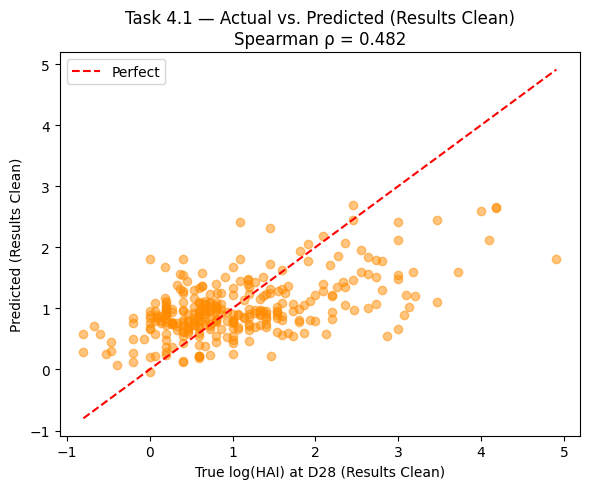

In [73]:
actual_values = results_clean['actual'].as_data_frame().to_numpy()
predicted_values = results_clean['predicted'].as_data_frame().to_numpy()

rho_results, pval_results = spearmanr(actual_values, predicted_values)
print(f'Spearman (results_clean): {rho_results:.3f}  (p-value: {pval_results:.4f})')

plt.figure(figsize=(6, 5))
plt.scatter(actual_values, predicted_values, alpha=0.5, color='darkorange')
plt.plot([actual_values.min(), actual_values.max()], [actual_values.min(), actual_values.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28 (Results Clean)')
plt.ylabel('Predicted (Results Clean)')
plt.title(f'Task 4.1 — Actual vs. Predicted (Results Clean)\nSpearman ρ = {rho_results:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

First 5 actual HAI D28 values (Original Scale):
 [[422.24253145]
 [ 45.9479342 ]
 [139.28809013]
 [139.28809013]
 [121.25732532]]

First 5 predicted HAI D28 values (Original Scale):
 [[410.76189243]
 [ 69.68551748]
 [143.53014064]
 [109.59102485]
 [139.49514331]]


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


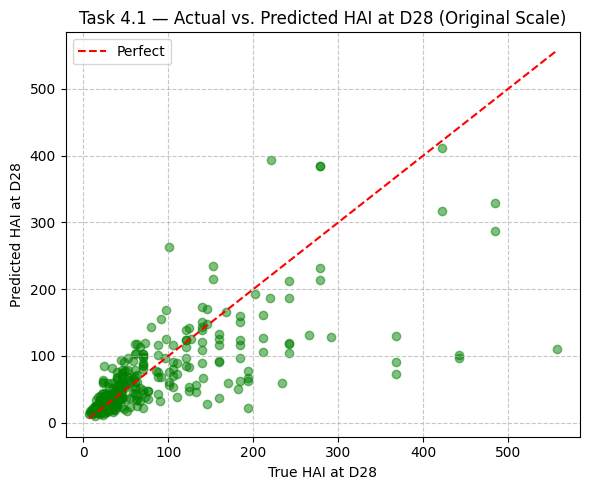

In [74]:
# Flag to toggle between log scale (1) and original scale (0) results
convert_to_original_scale = 0 # Set to 0 for original scale, 1 for log2 scale

# Get the Day 0 HAI values for the test set corresponding to the cleaned results
test_d0_hai_column_name = 'geomean_d0'

# Filter the original 'test' H2OFrame using the same condition that created results_clean.
# results_clean was created from `results[results["actual"].isna() == 0]`,
# where `results["actual"]` corresponds to `test[y]` for the relevant rows.
filtered_test_for_d0_h2o = test[test[y].isna() == 0]

# Now, extract the d0 HAI column from this filtered H2OFrame
test_d0_hai_h2o_filtered = filtered_test_for_d0_h2o[test_d0_hai_column_name]

# Convert it to a numpy array. The 'actual_values' and 'predicted_values' are already numpy arrays.
test_d0_hai = test_d0_hai_h2o_filtered.as_data_frame().values.reshape(-1, 1)

# Calculate actual HAI d28 values (log2 scale)
actual_hai_d28_log2 = test_d0_hai + actual_values

# Calculate predicted HAI d28 values (log2 scale)
predicted_hai_d28_log2 = test_d0_hai + predicted_values

if convert_to_original_scale == 0:
    # Convert to original HAI titer scale (exp2)
    display_actual_values = np.exp2(actual_hai_d28_log2)
    display_predicted_values = np.exp2(predicted_hai_d28_log2)
    scale_label = 'Original Scale'
    x_label = 'True HAI at D28'
    y_label = 'Predicted HAI at D28'
else:
    display_actual_values = actual_hai_d28_log2
    display_predicted_values = predicted_hai_d28_log2
    scale_label = 'Log2 Scale'
    x_label = 'True log2(HAI) at D28'
    y_label = 'Predicted log2(HAI) at D28'

print(f"First 5 actual HAI D28 values ({scale_label}):\n", display_actual_values[:5])
print(f"\nFirst 5 predicted HAI D28 values ({scale_label}):\n", display_predicted_values[:5])

# Plotting the HAI values
plt.figure(figsize=(6, 5))
plt.scatter(display_actual_values, display_predicted_values, alpha=0.5, color='green')
plt.plot([display_actual_values.min(), display_actual_values.max()],
         [display_actual_values.min(), display_actual_values.max()], 'r--', label='Perfect')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(f'Task 4.1 — Actual vs. Predicted HAI at D28 ({scale_label})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [75]:
#calculate the spearman
rho_results, pval_results = spearmanr(display_actual_values, display_predicted_values)

print(f'Spearman: {rho_results}')

Spearman: 0.8084928177328721


#Use AutoML model to predict challenge set

In [76]:
challenge_hf = h2o.H2OFrame(df_challenge)
y_pred_challenge = aml.leader.predict(challenge_hf).as_data_frame()['predict']

results = pd.DataFrame({
    'participant_id': df_challenge['participant_id'].values,
    'Task_4.5': np.exp2(y_pred_challenge),
})

results = results.merge(df_challenge[['participant_id', 'geomean_d0']], on='participant_id', how='inner')
results['Task_4.5'] = np.exp2(results['Task_4.5'] + results['geomean_d0'])
d0 = results.copy(deep=True)
results.drop(columns = ['geomean_d0'], inplace = True)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,participant_id,Task_4.5
0,2024_UGA.ID_077,39.492918
1,2024_UGA.ID_086,95.210197
2,2024_UGA.ID_128,256.015405
3,2024_UGA.ID_170,80.453936
4,2024_UGA.ID_179,90.056591
5,2024_UGA.ID_215,106.087593
6,2024_UGA.ID_219,118.036017
7,2024_UGA.ID_275,46.605685
8,2024_UGA.ID_295,70.061018
9,2024_UGA.ID_296,34.087283


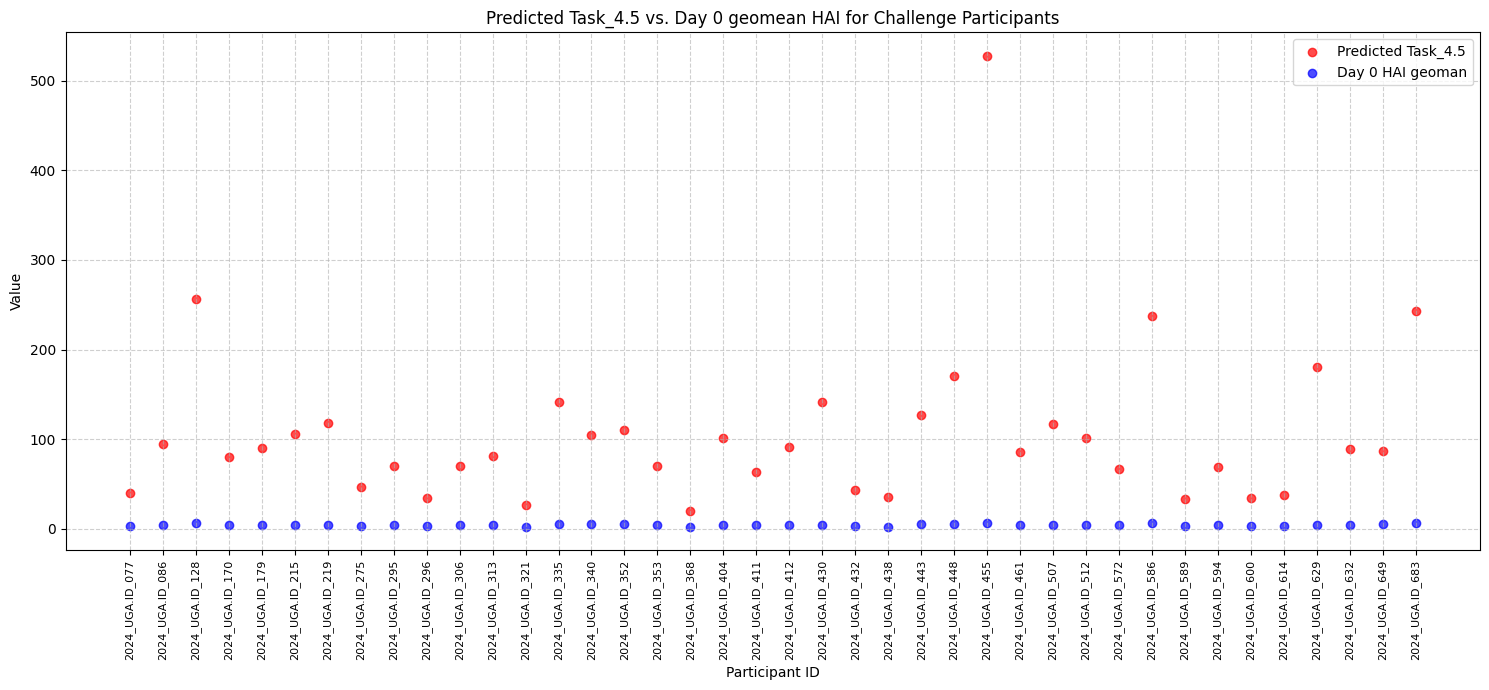

In [77]:
plt.figure(figsize=(15, 7))

# Plot predicted Task_4.5 values
plt.scatter(d0['participant_id'], d0['Task_4.5'], color='red', label='Predicted Task_4.5', alpha=0.7)

# Plot Day 0 HAI values (d0 value)
plt.scatter(d0['participant_id'], d0['geomean_d0'], color='blue', label='Day 0 HAI geoman', alpha=0.7)

plt.xlabel('Participant ID')
plt.ylabel('Value')
plt.title('Predicted Task_4.5 vs. Day 0 geomean HAI for Challenge Participants')
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for readability
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [78]:
results.to_csv(SUBMISSION_PATH + '/task_4_5.csv', index=False)